Goal: go from the HMF to the UVLF by parameterizing each step in the process \
Following Shen+23

In [2]:
import numpy as np
import zeus21
from classy import Class
import cosmo_calc
import importlib

In [3]:
z = 3

# HMF

In [8]:
M_vals = np.logspace(7, 14, 100)
params, HMFintclass = cosmo_calc.hmf_zeus(z = z)
hmf = HMFintclass.HMF_int(M_vals, z)

In [32]:
params

{'Omega_b': 0.04867734979810887,
 'Omega_m': 0.30988304304812053,
 'Omega_L': 0.6900259954953076,
 'h': 0.6727}

Text(0.5, 1.0, 'HMF, $z=3$')

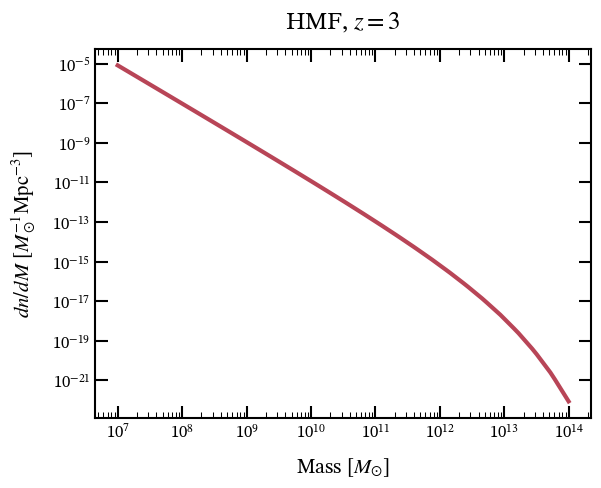

In [15]:
fig, ax = plt.subplots()
ax.loglog(M_vals, hmf)
ax.set_ylabel(r'$dn/dM$ [$M_\odot^{-1}\rm{Mpc}^{-3}$]')
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_title(f'HMF, $z={z}$')

# Mass accretion

In [34]:
def calc_M_dot(M_h, params, z = 0):
    return 25.3*(M_h/1e12)**(1.1)*(1+(1.65*z))*np.sqrt((params['Omega_m']*(1+z)**3)+params['Omega_L'])

In [35]:
m_dots = calc_M_dot(M_vals, params, z)

In [28]:
normalized_hmf = hmf/np.trapz(hmf, M_vals)

Text(0.5, 1.0, 'Mass accretion rate distribution')

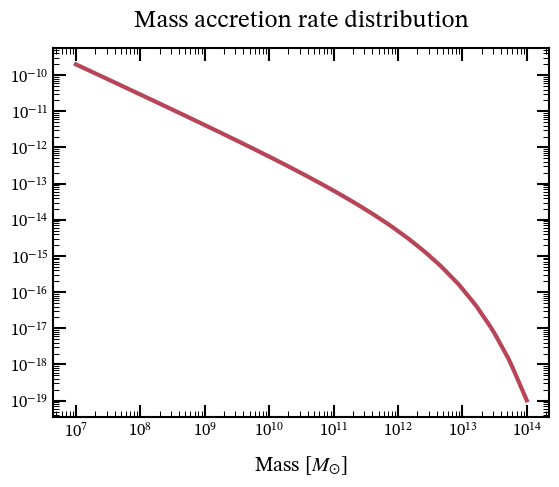

In [29]:
fig, ax = plt.subplots()
ax.loglog(M_vals, m_dots*normalized_hmf)
ax.set_xlabel(r'Mass [$M_{\odot}$]')
ax.set_title('Mass accretion rate distribution')

In [30]:
def SFE(M_h, eps_0 = 0.1, M_0 = 1e12, alpha = 0.6, beta = 0.5):
    return 2*eps_0/((M_h/M_0)**-alpha+(M_h/M_0)**beta)

In [36]:
def SFR(M_h, params, z=0):
    fb = params['Omega_b']/params['Omega_m']
    M_dot = calc_M_dot(M_h, params, z)
    eps_star = SFE(M_h)
    return fb*M_dot*eps_star

In [37]:
sfrs = SFR(M_vals, params, z)